# RNN Model Machine learning notebook for Industrial Analytics
Build by: Florian Schulz<br>
Goal: Build a machine learning model using RNN and visualize it's performance

## Setup
### Set Seeds for repeatable results

In [1]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


### Load enviroment variables and set up paths

In [2]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine

load_dotenv()

HOST, PWD, USER, PORT = '127.0.0.1', os.getenv("PWD"), os.getenv("USER"), '3306'

engine = create_engine(
    f"mysql+mysqlconnector://{USER}:{PWD}@{HOST}:{PORT}/mexico_toy_store_wh_db"
)

### Load Global demand data
The following cell loads all the demand of all shops into a pandas dataframe<br>
You can see that the data we are using is very uncomplicated, just the day and the total units sold across all shops, perfect for a first simple model

In [3]:
with open(r'../sql/rnn-query/units_sold_per_day_global.sql', 'r', encoding='utf-8') as f:
    query = f.read()

df = pd.read_sql(query, engine)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print('-----------------------------------------------')
print(df.info())

        date  total_units_sold
0 2022-01-01            2970.0
1 2022-01-02            2812.0
2 2022-01-03            1500.0
3 2022-01-04            1920.0
4 2022-01-05            2740.0
-----------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              638 non-null    datetime64[ns]
 1   total_units_sold  638 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.1 KB
None


### Set date as Index
Every day can be only once in the dataset, so we can use it as Index for our RNN later.<br>
We also check if there is any missing days, which we already know from our earlier presentation that there isn't.

In [4]:
df = df.set_index("date")

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

df = df.reindex(full_index)
df.index.name = "date"

# missing days = zero demand (retail assumption)
df["total_units_sold"] = df["total_units_sold"].fillna(0)

print("Missing dates after fill:", df.isna().sum())


Missing dates after fill: total_units_sold    0
dtype: int64


### Feature engineering
An RNN is a very simple machine learning model, it basically takes every factor you give it and tries to see an indication for it's next prediciton step.<br>
Features we add are:
<ul>
    <li>Weekdays (Maybe weekends have higher sales than weekdays)</li>
    <li>Count of day in the year (Christmas sales maybe around day 344 - 359, this is relevant for our model)</li>
    <li>Month (Some months are just higher in demand than others)</li>
    <li>Lag</li>
    <li>Rolling mean</li>
</ul>
Rolling mean and lag are great indicators for obvious patterns, which the RNN doesn't have to figure out by itself, you see how they behave on the graph below.
<br><br>
Important to notice is that RNN's can't deal with circularity, for an RNN it doesn't make sense why the count of days reset to 1 after 365. It understands consitent curves like Sin and Cos.

In [5]:
import numpy as np

# Create the first three features
df["day_of_week"] = df.index.dayofweek        # 0–6
df["day_of_year"] = df.index.dayofyear
df["month"] = df.index.month

# Encode them cyclical
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# lags, per day, week and fortneight
df["lag_1"] = df["total_units_sold"].shift(1)
df["lag_7"] = df["total_units_sold"].shift(7)
df["lag_14"] = df["total_units_sold"].shift(14)

# rolling mean weekly and monthly
df["roll_mean_7"] = df["total_units_sold"].rolling(7).mean()
df["roll_mean_30"] = df["total_units_sold"].rolling(30).mean()

# Drop all rows of first month because they have na values due to rolling mean and lag
df = df.dropna()

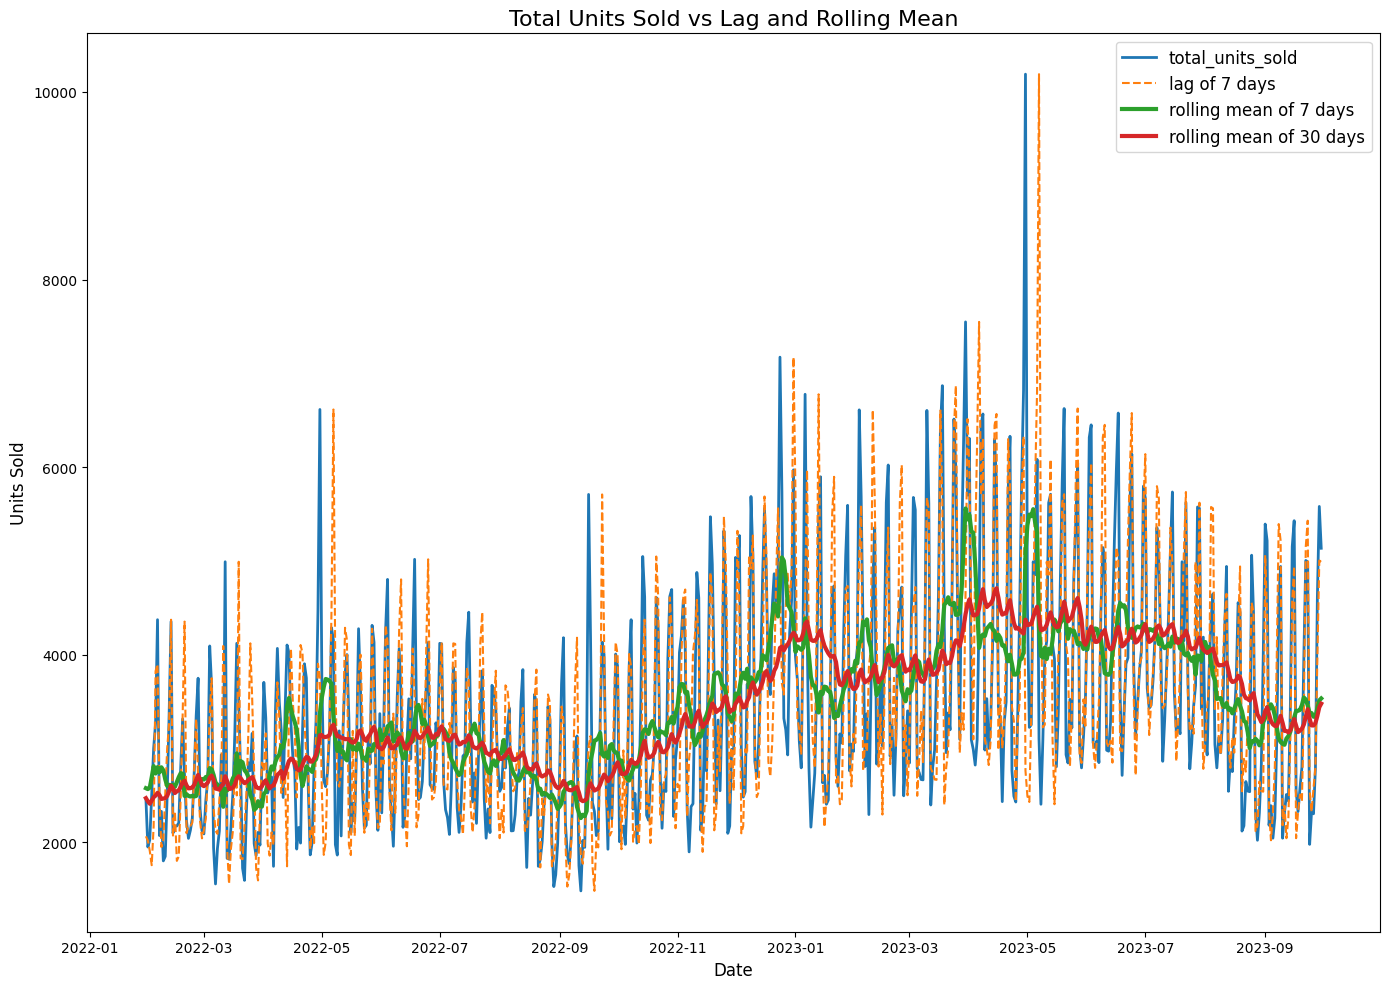

In [6]:
# Visualisation of Lag rolling mean and actual sales
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.plot(
    df.index,
    df["total_units_sold"],
    label="total_units_sold",
    linewidth=2
)

plt.plot(
    df.index,
    df["lag_7"],
    label="lag of 7 days",
    linestyle="--"
)

plt.plot(
    df.index,
    df["roll_mean_7"],
    label="rolling mean of 7 days",
    linewidth=3
)

plt.plot(
    df.index,
    df["roll_mean_30"],
    label="rolling mean of 30 days",
    linewidth=3
)


plt.title("Total Units Sold vs Lag and Rolling Mean", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)

plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig(r"../graphs/rnn/0_TotalUnitsSold_Lag_RollingMean.png", dpi=300, bbox_inches="tight")
plt.show()

### Splitting the dataset into train, validation and test
The split itself isn't that important, it's rather important that the split is time ordered, so that the validation data can be the future data.<br>
Rule of thumb is round about the time I want to predict, I should have in my validation set.<br>
1 year forecast --> validaton set of round about 1 year<br>
<ul><li>
    Train (70%) = used to fit model weights
</li><li>
    Validation (10%) = used for early stopping + hyperparameter tuning
</li><li>
    Test (20%) = untouched until the end
</li></ul>
Note: Important to split the dataset before scaling it, otherwise the scaler leaks future data!

In [7]:
N = len(df)
train_end = int(0.70 * N)
val_end   = int(0.80 * N)   # train + val = 80%, test = 20%

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

print("Train:", df_train.index.min(), "→", df_train.index.max())
print("Val  :", df_val.index.min(),   "→", df_val.index.max())
print("Test :", df_test.index.min(),  "→", df_test.index.max())
print(f'Days in total: {N}')
print(f'Amount of days the model will be trained on: {len(df_train)}, Amount of days in validation: {len(df_val)}, that is round about {round(len(df_val)/30, 2)} months of forecasting. Amount of days in Test: {len(df_test)}.')

Train: 2022-01-30 00:00:00 → 2023-03-31 00:00:00
Val  : 2023-04-01 00:00:00 → 2023-05-31 00:00:00
Test : 2023-06-01 00:00:00 → 2023-09-30 00:00:00
Days in total: 609
Amount of days the model will be trained on: 426, Amount of days in validation: 61, that is round about 2.03 months of forecasting. Amount of days in Test: 122.


### Scaling
Neural networks are using gradients, if we don't scale, large values like total_units_sold (Values like 2970.00) dominate and small values like dow_sin (it's from min -1 to max +1) become irrelevant.<br>
When everyhing is upscaled the target (y) also needs to be upscaled, otherwise we lose a huge amount of values.

In [8]:
from sklearn.preprocessing import StandardScaler

features = [
    "lag_1", "lag_7", "lag_14",
    "roll_mean_7", "roll_mean_30",
    "dow_sin", "dow_cos",
    "doy_sin", "doy_cos"
]

target = "total_units_sold"

scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(df_train[features])
y_train_scaled = scaler_y.fit_transform(df_train[[target]])

X_val_scaled   = scaler_X.transform(df_val[features])
y_val_scaled   = scaler_y.transform(df_val[[target]])

X_test_scaled  = scaler_X.transform(df_test[features])
y_test_scaled  = scaler_y.transform(df_test[[target]])

### Sequencing
An RNN is designed to process ordered data. A sequence is a fixed length of sequential values. SEQ_Len = 30 is basically saying look at the last 30 days and predict tomorrow.<br>
Note: Sequencing has to happen before Train/Validation-set Splitting otherwise the datasets will still have mixed days. But has to happen after the Future, Train split.

In [9]:
SEQ_LEN = 30

def build_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = build_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)
X_val_seq,   y_val_seq   = build_sequences(X_val_scaled,   y_val_scaled,   SEQ_LEN)
X_test_seq,  y_test_seq  = build_sequences(X_test_scaled,  y_test_scaled,  SEQ_LEN)

print("Train seq:", X_train_seq.shape, y_train_seq.shape)
print("Val seq  :", X_val_seq.shape, y_val_seq.shape)
print("Test seq :", X_test_seq.shape, y_test_seq.shape)

Train seq: (396, 30, 9) (396, 1)
Val seq  : (31, 30, 9) (31, 1)
Test seq : (92, 30, 9) (92, 1)


### Set up PyTorch dataset
Set up class to serve values for the training later on.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### GRU Model
Time series  models aren't that good in keeping long term information. The GRU model is a grat addition to a time series model, because it basicaly decides at each timestep if information should be forgotten or remembered. We can also try using LSTM later on, which is better for very longer sequences.<br>
Added dropout. Dropout randonly deactivates neurons while training. Has the advantage that the model can't rely on one path and has to look more into learning.

In [11]:
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


### Training loop

In [12]:
train_loader = DataLoader(
    TimeSeriesDataset(X_train_seq, y_train_seq),
    batch_size=32,
    shuffle=False
)

val_loader   = DataLoader(
    TimeSeriesDataset(X_val_seq,   y_val_seq),
    batch_size=32,
    shuffle=False
)

test_loader  = DataLoader(
    TimeSeriesDataset(X_test_seq,  y_test_seq),
    batch_size=32,
    shuffle=False
)

model = GRUModel(input_size=X_train_seq.shape[2])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print("X_train_seq shape:", X_train_seq.shape)
print("input_size (features):", X_train_seq.shape[2])

X_train_seq shape: (396, 30, 9)
input_size (features): 9


### Executing training

In [13]:
for epoch in range(20):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train {train_loss/len(train_loader):.4f} | "
        f"Val {val_loss/len(val_loader):.4f}"
    )

Epoch 01 | Train 0.9375 | Val 1.2144
Epoch 02 | Train 0.7850 | Val 0.9882
Epoch 03 | Train 0.6906 | Val 0.8406
Epoch 04 | Train 0.6190 | Val 0.7402
Epoch 05 | Train 0.5530 | Val 0.6588
Epoch 06 | Train 0.4916 | Val 0.5898
Epoch 07 | Train 0.4396 | Val 0.5374
Epoch 08 | Train 0.4003 | Val 0.5057
Epoch 09 | Train 0.3742 | Val 0.4936
Epoch 10 | Train 0.3585 | Val 0.4945
Epoch 11 | Train 0.3483 | Val 0.5006
Epoch 12 | Train 0.3404 | Val 0.5070
Epoch 13 | Train 0.3334 | Val 0.5122
Epoch 14 | Train 0.3269 | Val 0.5163
Epoch 15 | Train 0.3209 | Val 0.5200
Epoch 16 | Train 0.3153 | Val 0.5239
Epoch 17 | Train 0.3101 | Val 0.5285
Epoch 18 | Train 0.3052 | Val 0.5339
Epoch 19 | Train 0.3005 | Val 0.5403
Epoch 20 | Train 0.2961 | Val 0.5476


# Evaluation
## Scaled Actual vs Predicted plot
The model had a clean decreasing validation and training loss, based on the graph below the model is clearly underfitted.

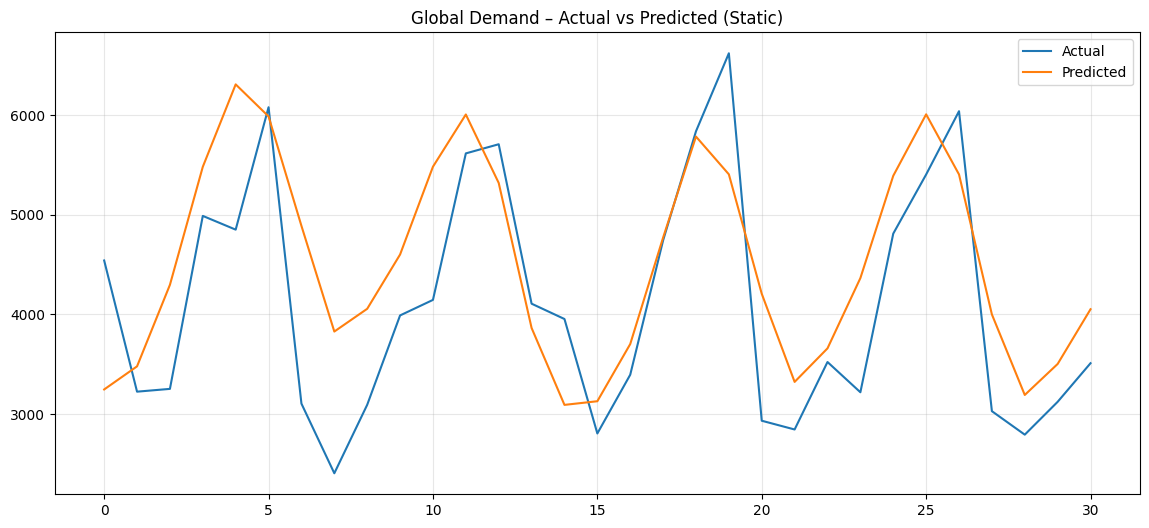

In [14]:
model.eval()
with torch.no_grad():
    val_preds = model(torch.tensor(X_val_seq, dtype=torch.float32)).cpu().numpy()

y_val_inv = scaler_y.inverse_transform(y_val_seq)
val_preds_inv = scaler_y.inverse_transform(val_preds)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_val_inv[:200], label="Actual")
plt.plot(val_preds_inv[:200], label="Predicted")
plt.title("Global Demand – Actual vs Predicted (Static)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(r"../graphs/rnn/GlobalDemandPredicitonVsActual.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluation metrics
### RMSE and MAE for the baseline model
RMSE and MAE on test set for testing the model performance. These are the baseline values, if the future model isn't better than this it gets ignored.<br>
Mean average error is good if its low.<br>
The idea of the gap is to see if outliers have negatively influenced the result. RMSE is more sensitive to outliers than MAE.

In [15]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

model.eval()
with torch.no_grad():
    test_preds = model(torch.tensor(X_test_seq, dtype=torch.float32)).cpu().numpy()

y_test_inv = scaler_y.inverse_transform(y_test_seq)
test_preds_inv = scaler_y.inverse_transform(test_preds)

rmse = root_mean_squared_error(y_test_inv, test_preds_inv)
mae  = mean_absolute_error(y_test_inv, test_preds_inv)

print(f"TEST RMSE: {rmse:.2f}")
print(f"TEST MAE : {mae:.2f}")
print(f"The gap between both is: {round(rmse - mae, 2)}")

TEST RMSE: 589.05
TEST MAE : 453.93
The gap between both is: 135.13


### Naive baseline 7-days
The idea of the baseline is to go back 7 days and use the last 7 days on the testset. If it performs worse than the GRU-Model, means that the model has an benefit in comparison with just using seasonal data.

In [16]:
# Seasonal naive baseline (7-day lag)
y_test_raw = df_test["total_units_sold"].values

seasonal_preds = y_test_raw[:-7]
seasonal_actuals = y_test_raw[7:]

baseline_mae = mean_absolute_error(seasonal_actuals, seasonal_preds)
baseline_rmse = root_mean_squared_error(seasonal_actuals, seasonal_preds)

print(f"Seasonal Naive RMSE: {baseline_rmse:.2f}")
print(f"Seasonal Naive MAE : {baseline_mae:.2f}")


Seasonal Naive RMSE: 587.38
Seasonal Naive MAE : 443.65


In [17]:
if baseline_mae <= mae:
    print(f'The model performs worse than the baseline. The model is on average {round(mae - baseline_mae, 2)} units per day wrong.')
elif baseline_mae > mae:
    print(f'The model performs better than the baseline. The model is on average {round(baseline_mae - mae, 2)} units per day above the baseline.')

The model performs worse than the baseline. The model is on average 10.28 units per day wrong.


### Seasonal Naive + Drift
The Series could have a trend which is a drift in the visualisation. Saying how much the demand changed over the last week. The model should be better in predicting the drift than this baseline.

In [18]:
y = df_test["total_units_sold"].values

pred = y[:-7] + (y[6:-1] - y[:-7])   # aligns carefully below
# easier: compute on full df with shifts; if you want I'll give the clean version

# Quick clean approach using pandas (recommended)
s = df_test["total_units_sold"]
pred = (s.shift(7) + (s.shift(1) - s.shift(8))).dropna()
act  = s.loc[pred.index]

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
print("Seasonal+drift MAE:", mean_absolute_error(act, pred))
print("Seasonal+drift RMSE:", root_mean_squared_error(act, pred))

Seasonal+drift MAE: 569.438596491228
Seasonal+drift RMSE: 736.1340934291604


### Error Analysis
In this section we are comparing three different timelines we have so far.
<ol>
    <li>Actual value</li>
    <li>GRU prediction</li>
    <li>Baseline prediction (seasonal naive)</li>
</ol>
First we determine the absolut error of the GRU Model, then we allign the baseline prediction with the rest of the predicitons. Because of the nature of the seasonal naive, the first 7 days have to be deleted, otherwise we would have NaN values in the first 7 days.

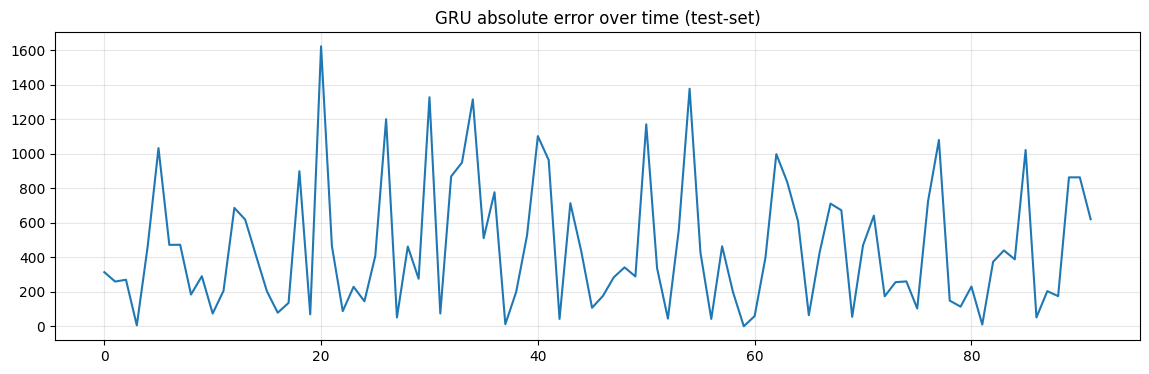

In [24]:
# Determine absolute error in GRU model
import numpy as np
err_gru = np.abs(y_test_inv.ravel() - test_preds_inv.ravel())

import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))
plt.plot(err_gru)
plt.title("GRU absolute error over time (test-set)")
plt.grid(alpha=0.3)
plt.show()

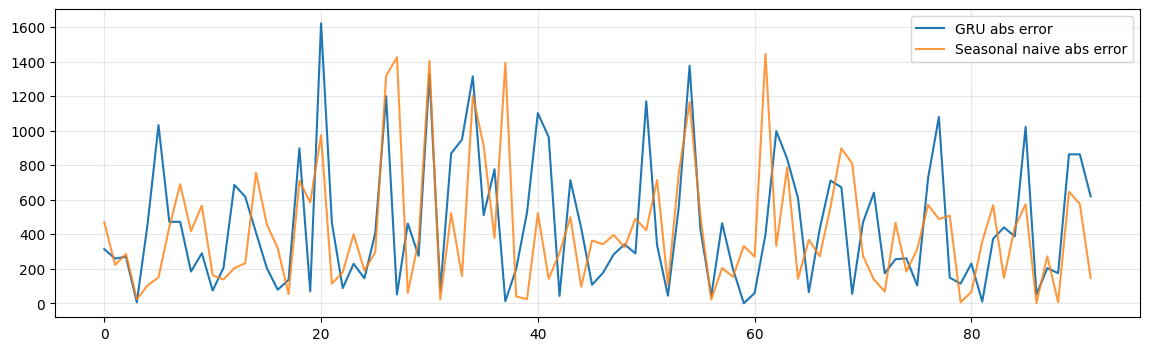

GRU MAE on comparable subset: 453.9274318529212
Baseline MAE on comparable subset: 422.95652173913044


In [27]:
# baseline seasonal 7 for the SAME test dates
s_test = df_test["total_units_sold"].copy()
base = s_test.shift(7)

# Align with test sequence
test_dates = df_test.index[SEQ_LEN:]
base_aligned = base.loc[test_dates].values.reshape(-1,1)

# Remove the first 7 days where baseline is NaN
mask = ~np.isnan(base_aligned.ravel()) # Inverted

gru_err = np.abs(y_test_inv.ravel()[mask] - test_preds_inv.ravel()[mask])
base_err = np.abs(y_test_inv.ravel()[mask] - base_aligned.ravel()[mask])

plt.figure(figsize=(14,4))
plt.plot(gru_err, label="GRU abs error")
plt.plot(base_err, label="Seasonal naive abs error", alpha=0.8)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(r"../graphs/rnn/GRU_compared_to_Baseline.png", dpi=300, bbox_inches="tight")
plt.show()

print("GRU MAE on comparable subset:", gru_err.mean())
print("Baseline MAE on comparable subset:", base_err.mean())

#### Key learnings
The GRU Model isn't continously worse, that means it's not completely useless. The baseline as well as the model seem to fail on peaks, which speaks for underfitting. It seems like the model performs overall better 
than the baseline on regular business days.
<p>We could now take best of both worlds and call it a day, but we can also try to finetune the model and see if something changes.</p>

## Feel out if it is even possible to fit the model properly on the little data
In this section I try deliberatly to overfit my model

In [28]:
# Dedicated overfit model and variables to not accidental undo previous work.
N_OVERFIT = 400  # try 200, 400, 800
X_of = X_train_seq[:N_OVERFIT]
y_of = y_train_seq[:N_OVERFIT]

overfit_model = GRUModel(
    input_size=X_train_seq.shape[2],
    hidden_size=256, # Give the model a huge memory to determine the next date from 32 > 256
    num_layers=2, # Double the GRU models determining the outcome from 1 > 2
    dropout=0.0 # No dropout for achiving overfit
).to(device)

optimizer = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()



In [29]:
# Training loop for a loooong time (300 epochs) to maximise overfitting
from torch.utils.data import DataLoader

of_loader = DataLoader(TimeSeriesDataset(X_of, y_of), batch_size=32, shuffle=True)

for epoch in range(300):  # yes, big number on purpose
    overfit_model.train()
    total_loss = 0.0

    for xb, yb in of_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = overfit_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 25 == 0:
        print(f"Epoch {epoch+1:03d} | Train loss: {total_loss/len(of_loader):.6f}")

Epoch 025 | Train loss: 0.180567
Epoch 050 | Train loss: 0.093957
Epoch 075 | Train loss: 0.030354
Epoch 100 | Train loss: 0.002260
Epoch 125 | Train loss: 0.001388
Epoch 150 | Train loss: 0.003223
Epoch 175 | Train loss: 0.002547
Epoch 200 | Train loss: 0.005433
Epoch 225 | Train loss: 0.001451
Epoch 250 | Train loss: 0.000560
Epoch 275 | Train loss: 0.000957
Epoch 300 | Train loss: 0.008969


OVERFIT TRAIN MAE: 62.61364992700442
OVERFIT TRAIN RMSE: 85.44352628369694


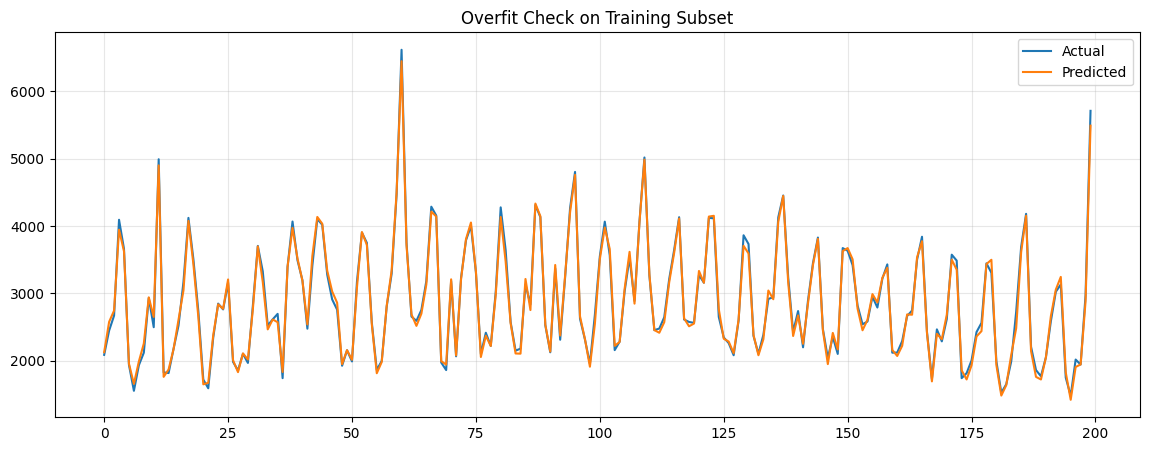

In [31]:
# Evaluate if Overfit actually is overfitted
overfit_model.eval()
with torch.no_grad():
    pred_scaled = overfit_model(torch.tensor(X_of, dtype=torch.float32).to(device)).cpu().numpy()

pred_inv = scaler_y.inverse_transform(pred_scaled)
y_inv    = scaler_y.inverse_transform(y_of)

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
print("OVERFIT TRAIN MAE:", mean_absolute_error(y_inv, pred_inv))
print("OVERFIT TRAIN RMSE:", root_mean_squared_error(y_inv, pred_inv))

import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.plot(y_inv[:200], label="Actual")
plt.plot(pred_inv[:200], label="Predicted")
plt.title("Overfit Check on Training Subset")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(r"../graphs/rnn/Overfitted_model.png", dpi=300, bbox_inches="tight")
plt.show()

#### Key takeaway
Overfitting is possible now it's about finding the middle for the perfect model.

### Walk forward backtest
At day t, what would my model have predicted knowing only the past?

In [19]:
# Inverse the scaling which we have done earlier
def inverse_transform_y(y_scaled, scaler):
    return scaler.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

In [20]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

def walk_forward_backtest(
    model_class,
    X_seq,
    y_seq,
    scaler_y,
    train_size,
    retrain_every=1,
    epochs=10,
    lr=1e-3
):
    preds = []
    actuals = []

    for t in range(train_size, len(X_seq)):
        X_train = X_seq[:t]
        y_train = y_seq[:t]
        X_test = X_seq[t:t+1]
        y_test = y_seq[t:t+1]

        # Reinitialize model periodically
        if (t - train_size) % retrain_every == 0:
            model = model_class(input_size=X_seq.shape[2])
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = torch.nn.MSELoss()

            # Train
            model.train()
            for _ in range(epochs):
                optimizer.zero_grad()
                preds_train = model(torch.tensor(X_train, dtype=torch.float32))
                loss = criterion(preds_train, torch.tensor(y_train, dtype=torch.float32))
                loss.backward()
                optimizer.step()

        # Predict next step
        model.eval()
        with torch.no_grad():
            pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

        preds.append(pred[0, 0])
        actuals.append(y_test[0, 0])

    # Inverse scale
    preds = inverse_transform_y(np.array(preds), scaler_y)
    actuals = inverse_transform_y(np.array(actuals), scaler_y)

    return preds, actuals

In [21]:
INITIAL_TRAIN_SIZE = int(0.6 * len(X_seq))

preds, actuals = walk_forward_backtest(
    model_class=GRUModel,
    X_seq=X_seq,
    y_seq=y_seq,
    scaler_y=scaler_y,
    train_size=INITIAL_TRAIN_SIZE,
    retrain_every=7,   # retrain weekly
    epochs=5
)

NameError: name 'X_seq' is not defined

In [ ]:
rmse = root_mean_squared_error(actuals, preds)
mae = mean_absolute_error(actuals, preds)

print(f"Backtest RMSE: {rmse:.2f}")
print(f"Backtest MAE : {mae:.2f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(actuals, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("Walk-Forward Backtest – Global Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(r"../graphs/rnn/WalkForwardBacktest.png", dpi=300, bbox_inches="tight")
plt.show()